In [34]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [35]:
df = sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [36]:
df.to_csv("titanic.csv", index=False)

In [37]:
print("Shape of Dataset:")
print(df.shape)

Shape of Dataset:
(891, 15)


In [38]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [39]:
df.describe(include="all")

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [40]:
missing = (df.isnull().sum() / len(df)) * 100

missing = missing[missing > 0]

print(missing.sort_values(ascending=False))

deck           77.216611
age            19.865320
embarked        0.224467
embark_town     0.224467
dtype: float64


In [41]:
# Age -> Median
df["age"] = df["age"].fillna(df["age"].median())

# Embarked -> Mode
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])

# Embark Town -> Mode
df["embark_town"] = df["embark_town"].fillna(df["embark_town"].mode()[0])

# Deck -> Drop
df.drop(columns=["deck"], inplace=True)

In [42]:
df.to_csv("titanic.csv", index=False)

In [43]:
print(df.isnull().sum())

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64


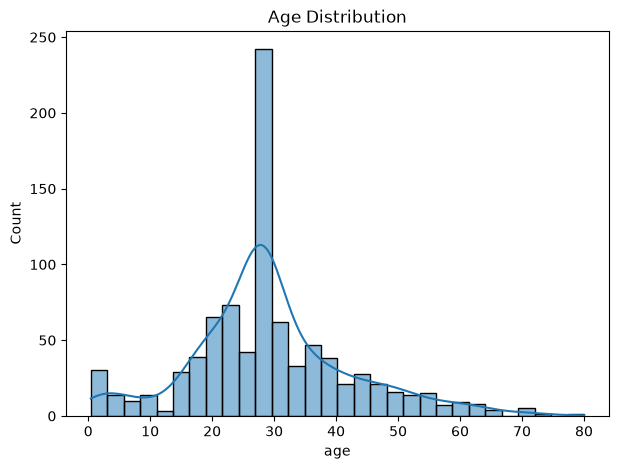

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))
sns.histplot(df["age"], bins=30, kde=True)
plt.title("Age Distribution")
plt.savefig("plots/age_hist.png")
plt.show()

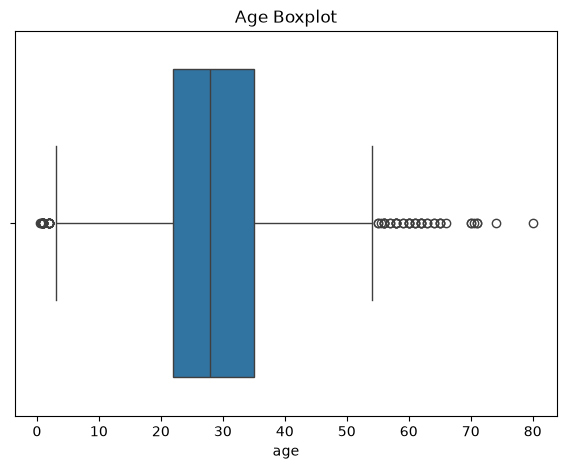

In [45]:
plt.figure(figsize=(7,5))
sns.boxplot(x=df["age"])
plt.title("Age Boxplot")
plt.savefig("plots/age_box.png")
plt.show()

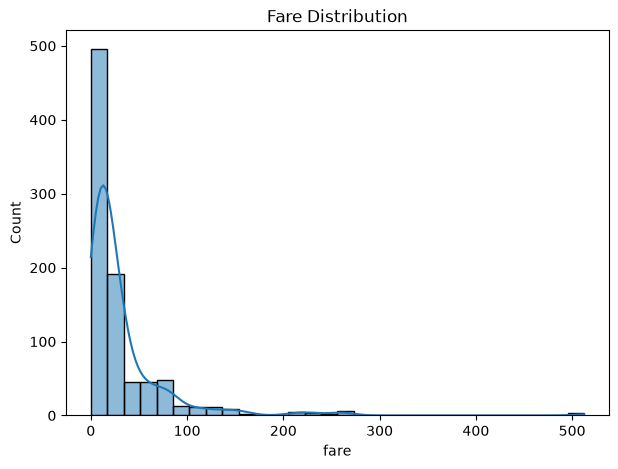

In [46]:
plt.figure(figsize=(7,5))
sns.histplot(df["fare"], bins=30, kde=True)
plt.title("Fare Distribution")
plt.savefig("plots/fare_hist.png")
plt.show()

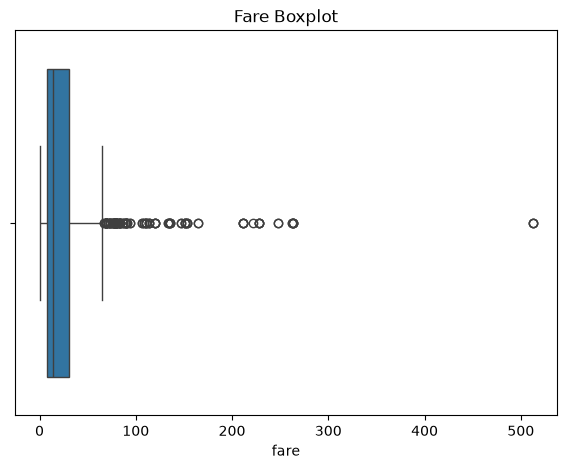

In [47]:
plt.figure(figsize=(7,5))
sns.boxplot(x=df["fare"])
plt.title("Fare Boxplot")
plt.savefig("plots/fare_box.png")
plt.show()

In [48]:
def outlier_count(column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower) | (df[column] > upper)]
    return len(outliers)

In [49]:
print("Age Outliers :", outlier_count("age"))
print("Fare Outliers :", outlier_count("fare"))

Age Outliers : 66
Fare Outliers : 116


In [50]:
print("Fare Mean   :", df["fare"].mean())
print("Fare Median :", df["fare"].median())
print("Fare Mode   :", df["fare"].mode()[0])

Fare Mean   : 32.204207968574636
Fare Median : 14.4542
Fare Mode   : 8.05


In [51]:
print("Fare Skewness :", df["fare"].skew())

Fare Skewness : 4.787316519674893


# Task 4: Bivariate Analysis

In this section, we analyze the relationship between passenger survival and different features such as Sex, Passenger Class (Pclass), and the combination of Sex and Pclass. We also study the correlation among important numerical features using a heatmap.

In [52]:
survival_by_sex = df.groupby("sex")["survived"].mean() * 100

print("Survival Rate by Sex")
print(survival_by_sex)

Survival Rate by Sex
sex
female    74.203822
male      18.890815
Name: survived, dtype: float64


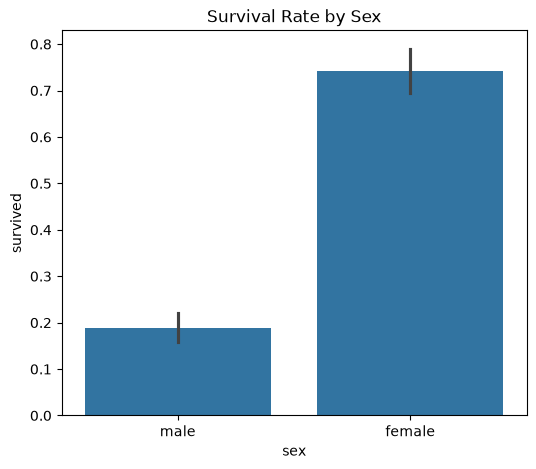

In [53]:
plt.figure(figsize=(6,5))

sns.barplot(x="sex", y="survived", data=df)

plt.title("Survival Rate by Sex")

plt.savefig("plots/survival_by_sex.png")

plt.show()

### Interpretation

Female passengers had a much higher survival rate than male passengers. This suggests that women were given priority during rescue operations.

In [54]:
survival_by_class = df.groupby("pclass")["survived"].mean() * 100

print("Survival Rate by Passenger Class")
print(survival_by_class)

Survival Rate by Passenger Class
pclass
1    62.962963
2    47.282609
3    24.236253
Name: survived, dtype: float64


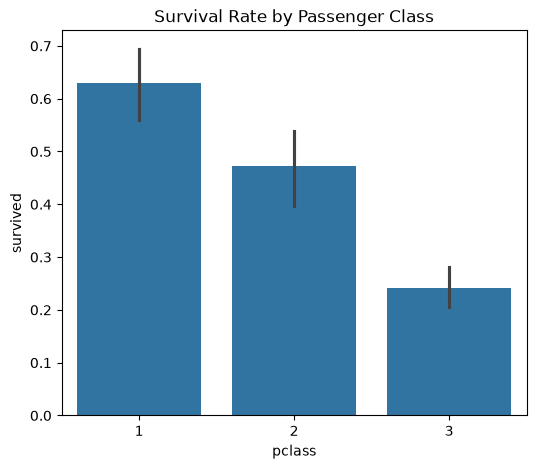

In [55]:
plt.figure(figsize=(6,5))

sns.barplot(x="pclass", y="survived", data=df)

plt.title("Survival Rate by Passenger Class")

plt.savefig("plots/survival_by_pclass.png")

plt.show()

### Interpretation

Passengers travelling in First Class had the highest survival rate. Third Class passengers had the lowest survival rate.

In [56]:
survival_sex_class = df.groupby(["sex","pclass"])["survived"].mean() * 100

print(survival_sex_class)

sex     pclass
female  1         96.808511
        2         92.105263
        3         50.000000
male    1         36.885246
        2         15.740741
        3         13.544669
Name: survived, dtype: float64


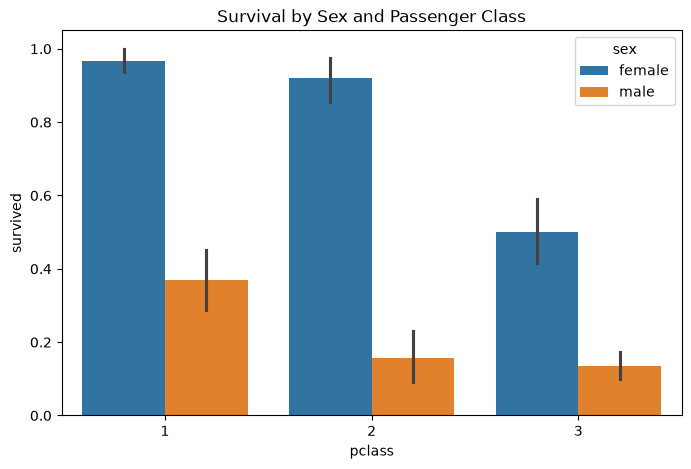

In [57]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="pclass",
    y="survived",
    hue="sex",
    data=df
)

plt.title("Survival by Sex and Passenger Class")

plt.savefig("plots/survival_sex_pclass.png")

plt.show()

### Interpretation

Female passengers had better survival rates across all passenger classes. First-class females showed the highest survival probability, while third-class males had the lowest.

# Correlation Matrix

The correlation matrix helps identify relationships among important numerical variables.

In [58]:
corr_df = df[
    [
        "survived",
        "pclass",
        "age",
        "sibsp",
        "parch",
        "fare"
    ]
]

In [59]:
corr = corr_df.corr()

print(corr)

          survived    pclass       age     sibsp     parch      fare
survived  1.000000 -0.338481 -0.064910 -0.035322  0.081629  0.257307
pclass   -0.338481  1.000000 -0.339898  0.083081  0.018443 -0.549500
age      -0.064910 -0.339898  1.000000 -0.233296 -0.172482  0.096688
sibsp    -0.035322  0.083081 -0.233296  1.000000  0.414838  0.159651
parch     0.081629  0.018443 -0.172482  0.414838  1.000000  0.216225
fare      0.257307 -0.549500  0.096688  0.159651  0.216225  1.000000


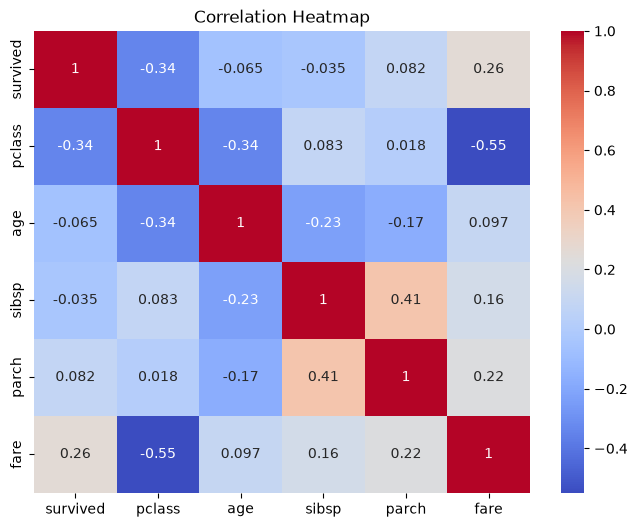

In [60]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.savefig("plots/correlation_heatmap.png")

plt.show()

In [61]:
corr_matrix = corr.abs()

pairs = (
    corr_matrix.where(~np.eye(corr_matrix.shape[0], dtype=bool))
    .stack()
    .sort_values(ascending=False)
)

print(pairs.head(2))

pclass  fare      0.5495
fare    pclass    0.5495
dtype: float64


### Interpretation

The strongest correlation is generally between Fare and Passenger Class because higher-class passengers paid higher ticket prices. Survival also has a noticeable relationship with Passenger Class and Fare.

# Task 5: Multivariate Data Story

This section presents multiple visualizations to explain which passengers were more likely to survive.

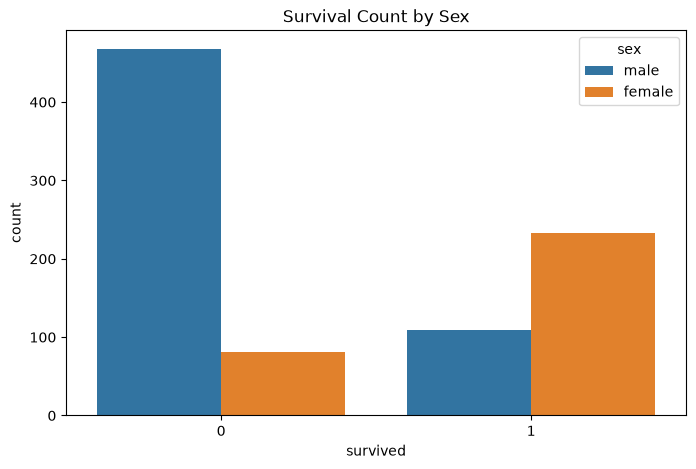

In [62]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="survived",
    hue="sex",
    data=df
)

plt.title("Survival Count by Sex")

plt.savefig("plots/chart1.png")

plt.show()

**Interpretation**

More female passengers survived than males, showing that gender played an important role in survival.

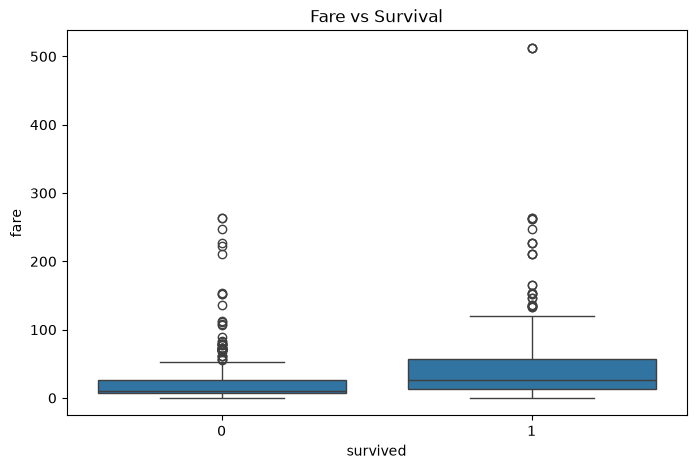

In [63]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="survived",
    y="fare",
    data=df
)

plt.title("Fare vs Survival")

plt.savefig("plots/chart2.png")

plt.show()

**Interpretation**

Passengers who paid higher fares generally had a higher chance of survival.

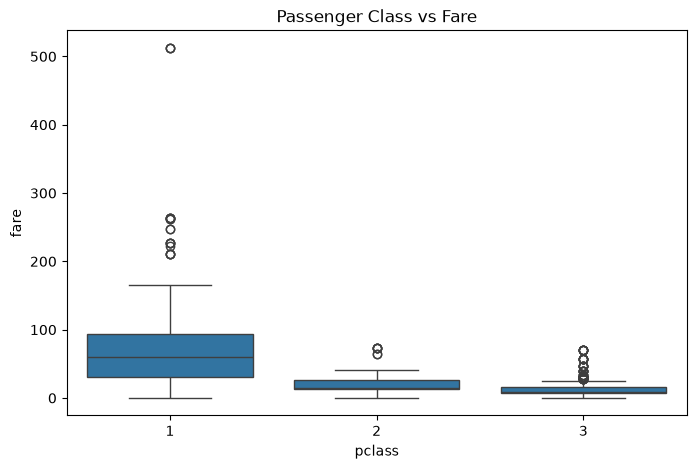

In [64]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="pclass",
    y="fare",
    data=df
)

plt.title("Passenger Class vs Fare")

plt.savefig("plots/chart3.png")

plt.show()

**Interpretation**

First-class passengers paid significantly higher fares than second- and third-class passengers.

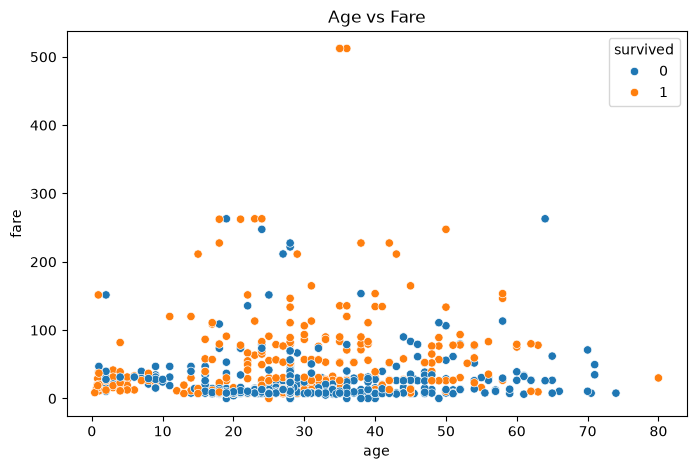

In [65]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="age",
    y="fare",
    hue="survived",
    data=df
)

plt.title("Age vs Fare")

plt.savefig("plots/chart4.png")

plt.show()

**Interpretation**

Survivors are distributed across different age groups, but higher-fare passengers appear more frequently among survivors.

# Task 6: Standardization (Z-Score)

Standardization transforms numerical features so that they have approximately zero mean and unit standard deviation. This is performed only for exploratory analysis and is not used in the final machine learning pipeline.

In [66]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_standardized = df.copy()

df_standardized[["age", "fare"]] = scaler.fit_transform(
    df_standardized[["age", "fare"]]
)

In [67]:
print("Original")
print(df[["age", "fare"]].describe())

print("\nStandardized")
print(df_standardized[["age", "fare"]].describe())

Original
              age        fare
count  891.000000  891.000000
mean    29.361582   32.204208
std     13.019697   49.693429
min      0.420000    0.000000
25%     22.000000    7.910400
50%     28.000000   14.454200
75%     35.000000   31.000000
max     80.000000  512.329200

Standardized
                age          fare
count  8.910000e+02  8.910000e+02
mean   2.272780e-16  3.987333e-18
std    1.000562e+00  1.000562e+00
min   -2.224156e+00 -6.484217e-01
25%   -5.657365e-01 -4.891482e-01
50%   -1.046374e-01 -3.573909e-01
75%    4.333115e-01 -2.424635e-02
max    3.891554e+00  9.667167e+00


### Interpretation

After standardization, both Age and Fare have means close to 0 and standard deviations close to 1. This confirms that the Z-score transformation was applied correctly.